In [21]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import h5py
from trainingTools import make_flow, train
import torch
import torch.nn as nn

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":6,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
fname = "lossEvals_pcaDecorr_boxCox/BKG.h5"
axes = ["BKG_mjjFlat","M80-80","M80-170","M80-400","M170-170","M170-400","M400-400"]
bkg_axis = 'BKG_mjjFlat'
n_var = len(axes)
data = []
with h5py.File(fname,'r') as f:
    for a in axes:
        data.append(f[a][()].reshape(-1,1))
    bloss_bkg = f[bkg_axis][()]
data = np.concatenate(data,axis=1)
mean = data.mean()
data = data-mean
vmax = np.max(data,axis=0)
vmin = np.min(data,axis=0)
scale = np.where(np.abs(vmax)>np.abs(vmin),np.abs(vmax),np.abs(vmin))
data = 3*(data/scale)
#mean = data.mean(axis=0)
#std = data.std(axis=0)
#data = data-mean

100000 training events
Iteration 10 Complete
Loss:  -6.940243721008301
Iteration 20 Complete
Loss:  -7.561301231384277
Iteration 30 Complete
Loss:  -7.689451217651367
Iteration 40 Complete
Loss:  -7.7267608642578125
Iteration 50 Complete
Loss:  -7.7388386726379395
Iteration 60 Complete
Loss:  -7.732280254364014
Iteration 70 Complete
Loss:  -7.702527046203613
Iteration 80 Complete
Loss:  -7.400982856750488


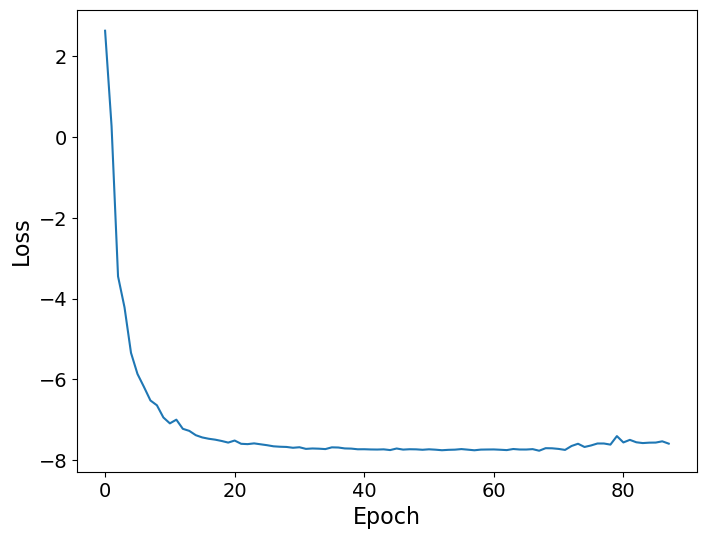

In [37]:
flow = make_flow(n_var,NF_kwargs)
rng = np.random.default_rng(seed=18592)
trainData = rng.choice(data,100000,replace=False)
flow = train(flow,trainData,NF_kwargs)

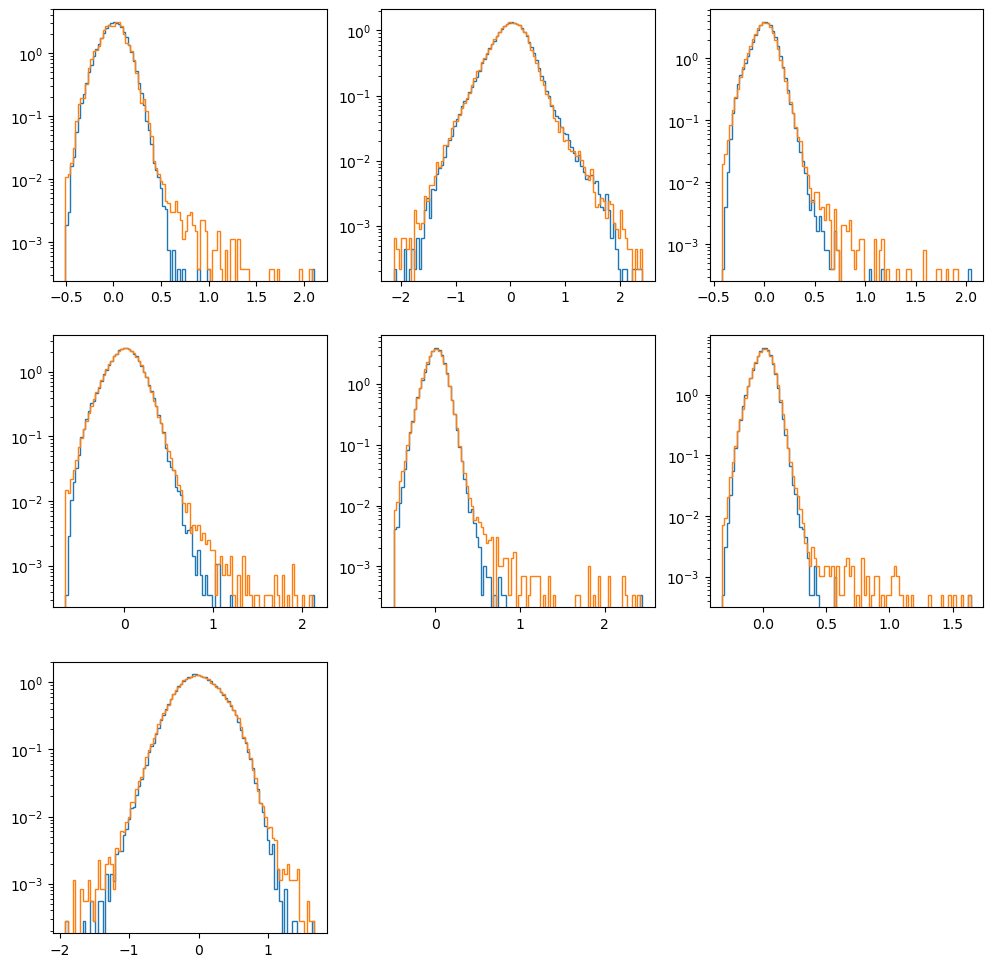

In [38]:
testData = rng.choice(data,100000,replace=False)
with torch.no_grad():
    sampled = flow.sample(100000).detach().cpu().numpy()
plt.figure(figsize=(12,12))
for i in range(testData.shape[1]):
    plt.subplot(3,3,i+1)
    h,bins,_ = plt.hist(testData[:,i],histtype='step',density=True,bins=100)
    h,bins,_ = plt.hist(sampled[:,i],histtype='step',density=True,bins=bins)
    plt.yscale('log')

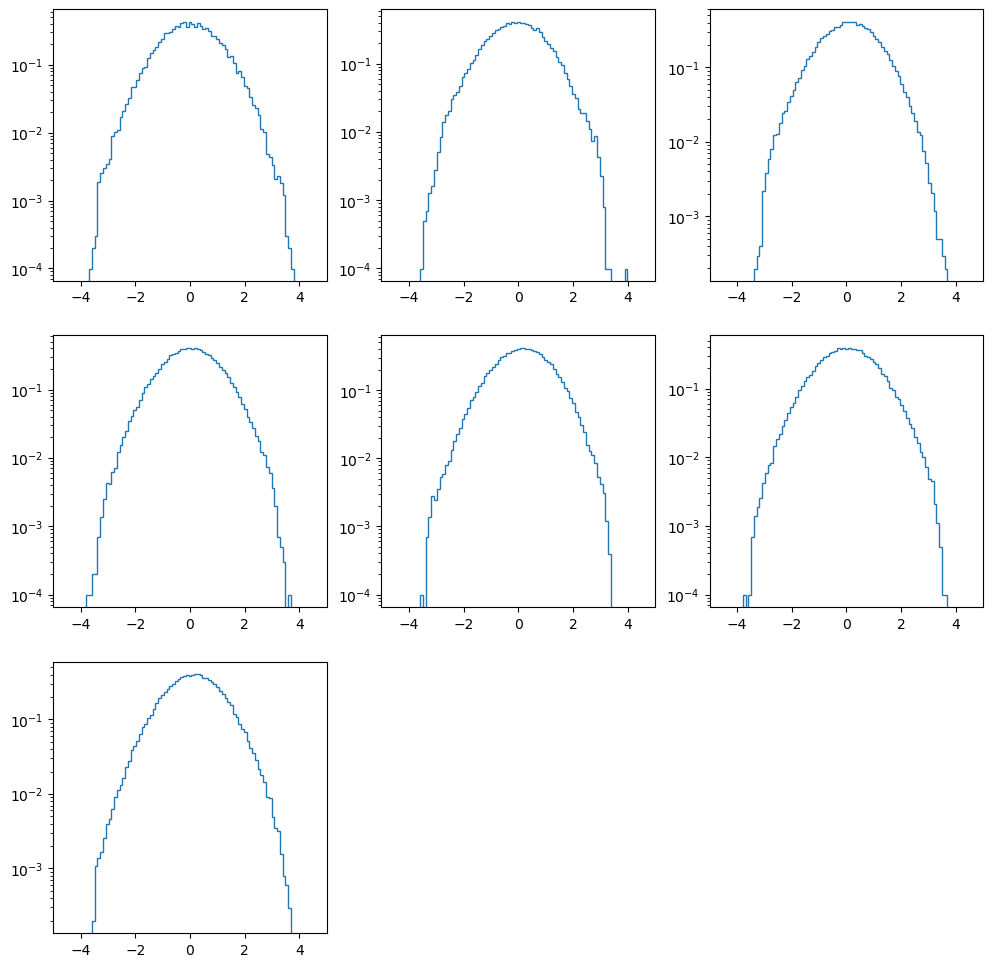

In [39]:
with torch.no_grad():
    transformed = flow.transform_to_noise(torch.tensor(testData,dtype=torch.float32,device='cuda:0')).detach().cpu().numpy()
plt.figure(figsize=(12,12))
for i in range(testData.shape[1]):
    plt.subplot(3,3,i+1)
    h,bins,_ = plt.hist(transformed[:,i],histtype='step',density=True,bins=np.linspace(-5,5,100))
    plt.yscale('log')
    plt.xlim([-5,5])

In [40]:
signame = "lossEvals_pcaDecorr_boxCox/XYY3000_Y170_Yp170.h5"
sig = []
with h5py.File(signame,'r') as f:
    for a in axes:
        sig.append(f[a][()].reshape(-1,1))
    bloss_sig = f[bkg_axis][()]
sig = np.concatenate(sig,axis=1)
sig = sig-mean
sig = 3*(sig/scale)
#sig = sig-mean

In [41]:
with torch.no_grad():
    t_bkg = []
    for vtest in np.array_split(data,data.shape[0]//100000+1,axis=0):
        v = torch.tensor(vtest,dtype=torch.float32,device='cuda:0')
        t_bkg.append(flow.transform_to_noise(v).detach().cpu().numpy())
        del v
        torch.cuda.empty_cache()
    t_bkg = np.concatenate(t_bkg,axis=0)
    vsig = torch.tensor(sig,dtype=torch.float32,device='cuda:0')
    t_sig = flow.transform_to_noise(vsig).detach().cpu().numpy()
    del vsig
    torch.cuda.empty_cache()

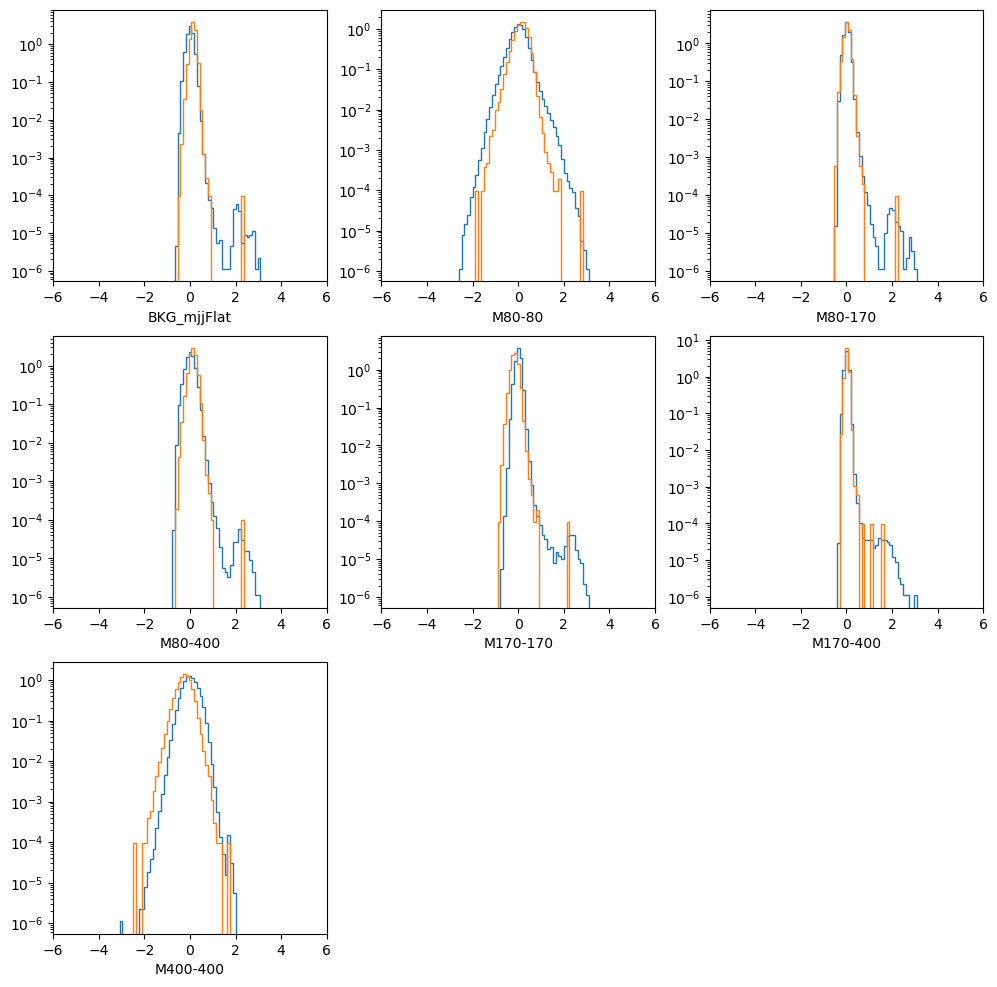

In [42]:
plt.figure(figsize=(12,12))
for i in range(testData.shape[1]):
    plt.subplot(3,3,i+1)
    lim = 6
    h,bins,_ = plt.hist(data[:,i],histtype='step',density=True,bins=np.linspace(-lim,lim,100))
    h,bins,_ = plt.hist(sig[:,i],histtype='step',density=True,bins=np.linspace(-lim,lim,100))
    plt.yscale('log')
    plt.xlim([-lim,lim])
    plt.xlabel(axes[i])

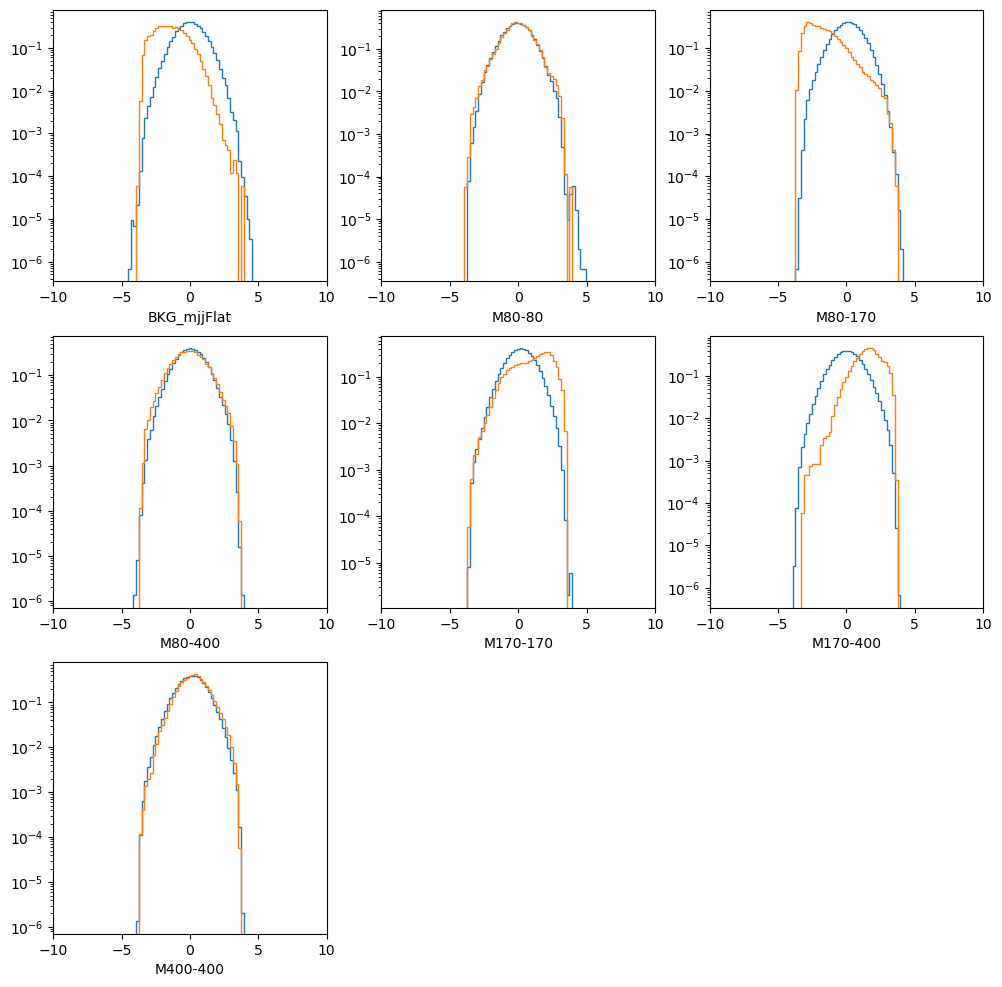

In [43]:
plt.figure(figsize=(12,12))
for i in range(testData.shape[1]):
    plt.subplot(3,3,i+1)
    h,bins,_ = plt.hist(t_bkg[:,i],histtype='step',density=True,bins=np.linspace(-10,10,100))
    h,bins,_ = plt.hist(t_sig[:,i],histtype='step',density=True,bins=np.linspace(-10,10,100))
    plt.yscale('log')
    plt.xlim([-10,10])
    plt.xlabel(axes[i])

In [44]:
from quakSpaceMaker import reductions
print(reductions.keys())

dict_keys(['inv2norm', 'inv5norm', 'inv10norm', 'inv2norm_o10', 'inv5norm_o10', 'inv10norm_o10', 'l5', 'l4', 'l3', 'l2', 'l1', 'Min', 'Sum', 'SumProb', 'SumProbNeg', 'SumExpAbs', 'LogSumExpAbs', 'chi2z', 'chi2sf', 'chiz', 'chisf', 'chicdf', 'radialGauss', 'None', 'signedL0', 'signedL1', 'signedL2', 'signedL3', 'signedL4', 'signedL5', 'signedL6', 'signedL7', 'signedL8', 'signedL9', 'signedL10'])


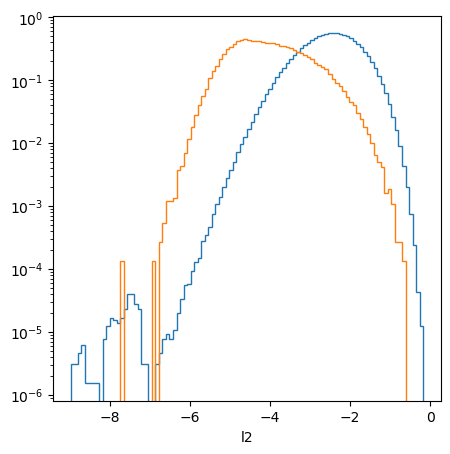

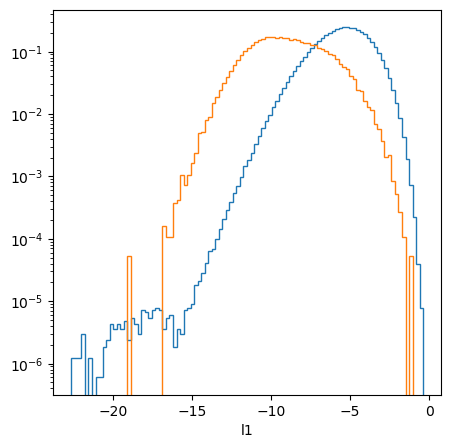

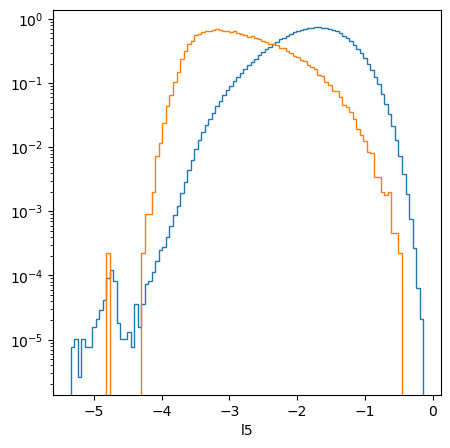

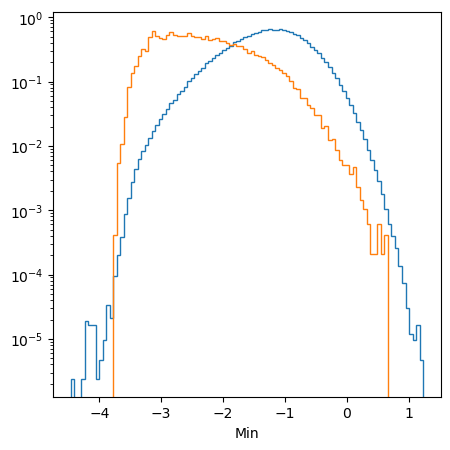

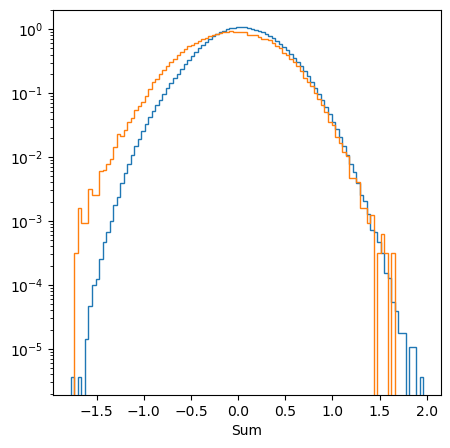

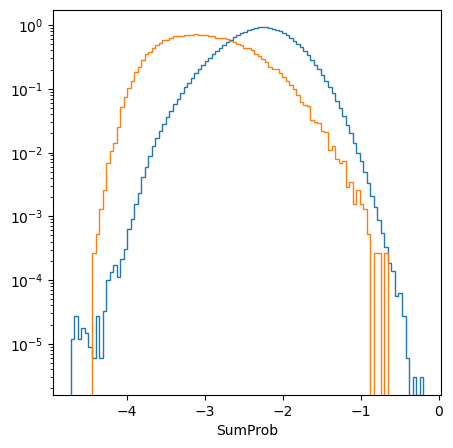

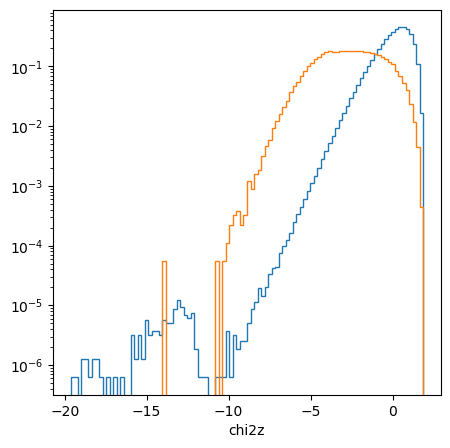

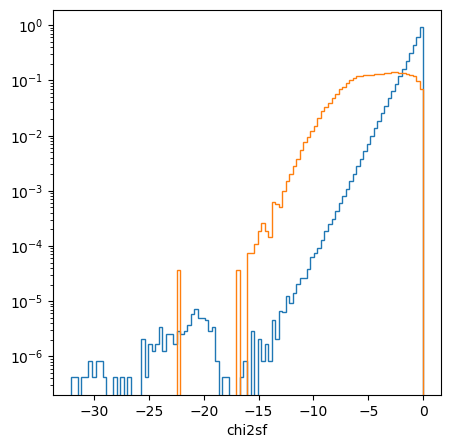

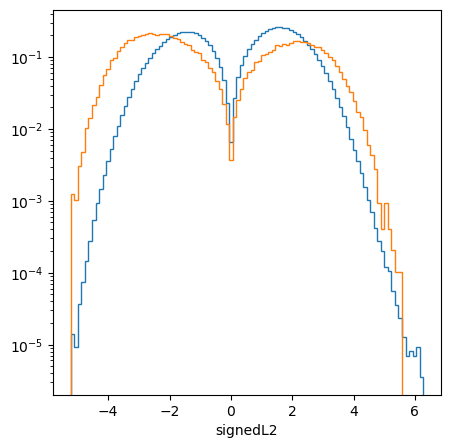

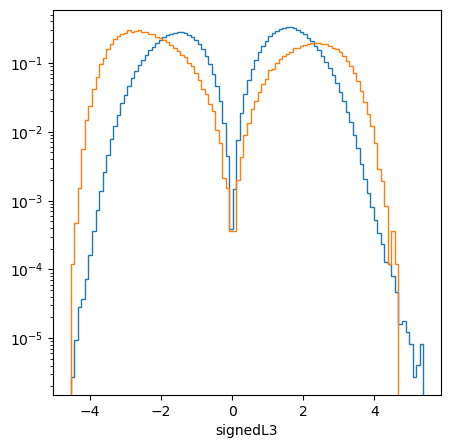

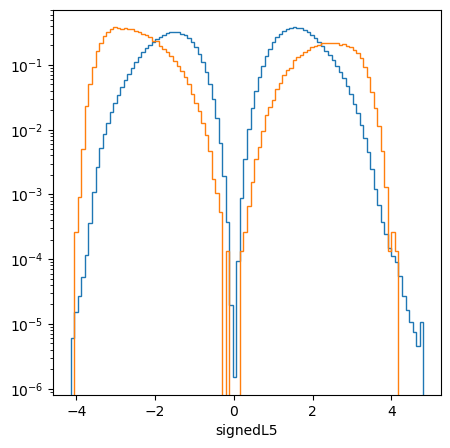

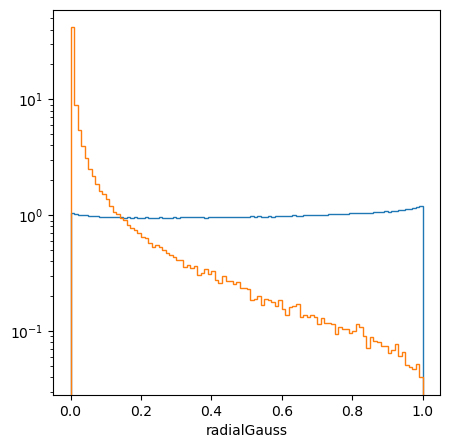

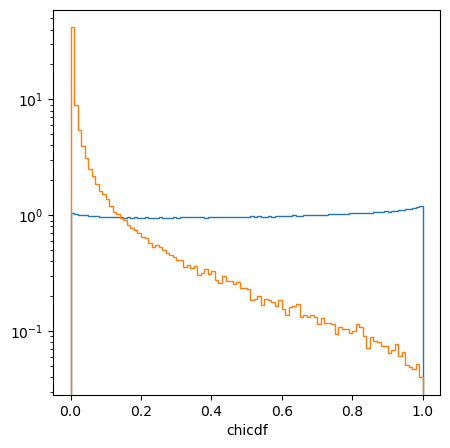

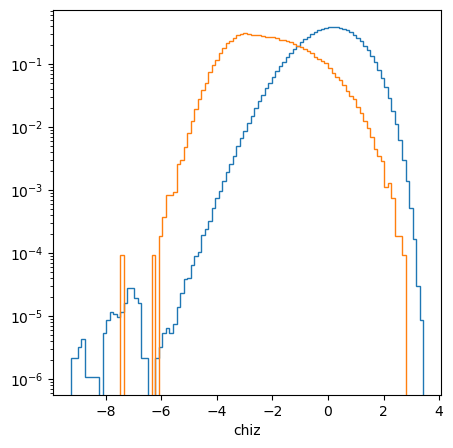

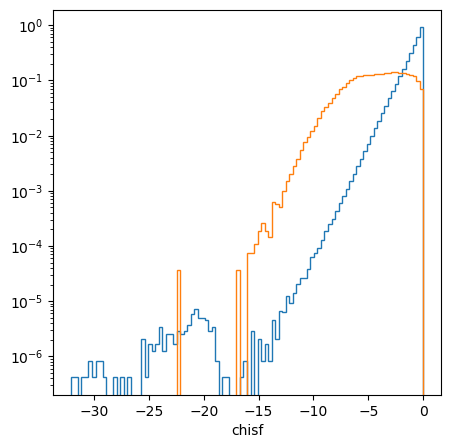

In [45]:
reducs = ['l2','l1','l5','Min','Sum','SumProb','chi2z','chi2sf','signedL2','signedL3','signedL5','radialGauss','chicdf','chiz','chisf']
for r in reducs:
    plt.figure(figsize=(5,5))
    h,bins,_ = plt.hist(reductions[r].transform(t_bkg),bins=100,histtype='step',density=True)
    h,bins,_ = plt.hist(reductions[r].transform(t_sig),bins=bins,histtype='step',density=True)
    plt.xlabel(r)
    plt.yscale('log')

In [46]:
with torch.no_grad():
    p_bkg = []
    for vtest in np.array_split(data,data.shape[0]//100000+1,axis=0):
        v = torch.tensor(vtest,dtype=torch.float32,device='cuda:0')
        p_bkg.append(flow.log_prob(v)[0].detach().cpu().numpy())
        del v
        torch.cuda.empty_cache()
    p_bkg = np.concatenate(p_bkg,axis=0)
    vsig = torch.tensor(sig,dtype=torch.float32,device='cuda:0')
    p_sig = flow.log_prob(vsig)[0].detach().cpu().numpy()
    del vsig
    torch.cuda.empty_cache()

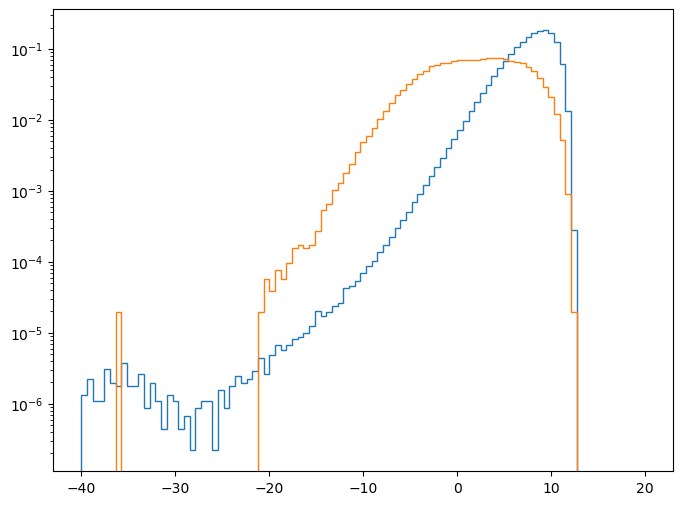

In [47]:
plt.figure(figsize=(8,6))
h1,bins,_ = plt.hist(p_bkg,bins=np.linspace(-40,20,100),histtype='step',density=True)
h1 = plt.hist(p_sig,bins=bins,histtype='step',density=True)
plt.yscale('log')

# Train models on background signal losses, save model losses + gaussian transforms to output files

In [2]:
# calculate mins/maxes of all losses
import json
def calcMinMaxes(base):
    import os
    from tqdm import tqdm
    files = [f for f in os.listdir(base) if ".h5" in f]
    with h5py.File(base+"BKG.h5","r") as f:
        axes = list(f.keys())
    systematics = ["JES_up","JES_down","JER_up","JER_down","JMS_up","JMS_down","JMR_up","JMR_down"]
    mins = {a:99999 for a in axes}
    maxes = {a:-99999 for a in axes}
    for lf in tqdm(files):
        with h5py.File(base+lf,"r") as f:
            for a in axes:
                possible = [a] + [f"{a}_{s}" for s in systematics]
                relevant = [k for k in list(f.keys()) if k in possible]
                for ax in relevant:
                    d = f[ax][()]
                    lo = float(d.min())
                    hi = float(d.max())
                    if lo < mins[a]:
                        mins[a] = lo
                    if hi > maxes[a]:
                        maxes[a] = hi
                    del d
    out = {'mins':mins,'maxes':maxes}
    with open(base+"minMax.json","w") as fout:
        json.dump(out,fout,indent=4)

In [6]:
# calculate means of all losses on bkg samples
import json
def calcMeans(base):
    import os
    from tqdm import tqdm
    files = ["BKG.h5"]
    with h5py.File(base+"BKG.h5","r") as f:
        axes = list(f.keys())
    systematics = ["JES_up","JES_down","JER_up","JER_down","JMS_up","JMS_down","JMR_up","JMR_down"]
    means = {}
    for lf in tqdm(files):
        with h5py.File(base+lf,"r") as f:
            for a in axes:
                means[a] = float(f[a][()].mean())
    with open(base+"bkg_meanLosses.json","w") as fout:
        json.dump(means,fout,indent=4)

In [3]:
calcMinMaxes('lossEvals_pcaDecorr_boxCox/')
calcMinMaxes('lossEvals_linearDecorr_boxCox/')
calcMinMaxes('lossEvals/')

100%|██████████| 89/89 [01:47<00:00,  1.21s/it]


In [7]:
calcMeans('lossEvals_pcaDecorr_boxCox/')
calcMeans('lossEvals_linearDecorr_boxCox/')
calcMeans('lossEvals/')

100%|██████████| 1/1 [00:01<00:00,  1.49s/it]


In [15]:
from trainingTools import make_flow, train
from trainingTools import make_flow, train
import torch
import torch.nn as nn
import numpy as np
import h5py
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

def loadData(base,file,axes):
    systematics = ["JES_up","JES_down","JER_up","JER_down","JMS_up","JMS_down","JMR_up","JMR_down"]
    axes_nosyst = [a for a in axes]
    for i in range(len(axes_nosyst)):
        for s in systematics:
            if s in axes_nosyst[i]:
                axes_nosyst[i] = axes_nosyst[i].replace(f"_{s}","")
                break
    
    data = []
    with h5py.File(f"{base}/{file}",'r') as f:
        for a in axes:
            data.append(f[a][()].reshape(-1,1))
    data = np.concatenate(data,axis=1)
    with open(f"{base}/minMax.json","r") as jsf:
        minmax = json.load(jsf)
    with open(f"{base}/bkg_meanLosses.json","r") as jsf:
        means = json.load(jsf)
    mins = minmax['mins']
    maxes = minmax['maxes']
    vmean = np.array([means[a] for a in axes_nosyst])
    vmax = np.array([maxes[a] for a in axes_nosyst])
    vmin = np.array([mins[a] for a in axes_nosyst])
    data = data-vmean
    scale = np.where(np.abs(vmax-vmean)>np.abs(vmin-vmean),np.abs(vmax-vmean),np.abs(vmin-vmean))
    data = 3*(data/scale)
    return data.astype('float32')

def trainEvalLossFlow(axes,flowName,NF_kwargs,nTrain=100000,base="lossEvals_pcaDecorr_boxCox",evalBatch=50000):
    # load train data, train flow
    data = loadData(base,"BKG.h5",axes)
    n_var = len(axes)
    flow = make_flow(n_var,NF_kwargs)
    rng = np.random.default_rng(seed=18592)
    trainData = rng.choice(data,nTrain,replace=False)
    NF_kwargs['axes'] = axes
    flow = train(flow,trainData,NF_kwargs,outName=f"{flowName}_{base}")
    
    # make density est plot
    testData = rng.choice(data,100000,replace=False)
    with torch.no_grad():
        sampled = flow.sample(100000).detach().cpu().numpy()
    plt.figure(figsize=(12,16))
    for i in range(testData.shape[1]):
        plt.subplot(4,3,i+1)
        h,bins,_ = plt.hist(testData[:,i],histtype='step',density=True,bins=100)
        h,bins,_ = plt.hist(sampled[:,i],histtype='step',density=True,bins=bins)
        plt.yscale('log')
        plt.xlabel(axes[i])
    plt.savefig(f"flow_on_losses/density_{flowName}_{base}.pdf")
    
    del data, trainData, testData
    
    # evaluate flow on all samples
    files = [f for f in os.listdir(base) if ".h5" in f]
    systematics = ["JES_up","JES_down","JER_up","JER_down","JMS_up","JMS_down","JMR_up","JMR_down"]
    varSets_sig = [axes] + [[f"{a}_{s}" for a in axes] for s in systematics]
    vnames_sig = [""]+[f"_{s}" for s in systematics]
    varSets_bkg = [axes]
    vnames_bkg = [""]
    for f in tqdm(files):
        print(f)
        if "BKG.h5" in f or "DATA" in f:
            varset = varSets_bkg
            names = vnames_bkg
        else:
            varset = varSets_sig
            names = vnames_sig
        for vset,vname in zip(varset,names):
            data = loadData(base,f,vset)
            nbatch = data.shape[0]//evalBatch + 1
            data = np.array_split(data,nbatch)
            embeds = []
            logps = []
            for batch in data:
                v = torch.tensor(batch,dtype=torch.float32,device='cuda:0')
                with torch.no_grad():
                    embeds.append(flow.transform_to_noise(v).detach().cpu().numpy())
                    logps.append(flow.log_prob(v)[0].detach().cpu().numpy())
                del v
                torch.cuda.empty_cache()
            embeds = np.concatenate(embeds,axis=0)
            logps = np.concatenate(logps,axis=0)
            outAxNames = [f"{ax}-{flowName}"+vname for ax in axes]
            with h5py.File(f"{base}/{f}",'r+') as fout:
                # create flow embeddings
                for i,oa in enumerate(outAxNames):
                    if oa in fout.keys():
                        del fout[oa]
                    fout.create_dataset(oa,data=embeds[:,i])
                # create flow log loss
                if flowName+vname in fout.keys():
                    del fout[flowName+vname]
                fout.create_dataset(flowName+vname,data=logps)

# on pca-decorrelated + boxcox samples

100000 training events
Iteration 10 Complete
Loss:  -7.81190299987793
Iteration 20 Complete
Loss:  -10.207866668701172
Iteration 30 Complete
Loss:  -10.502245903015137
Iteration 40 Complete
Loss:  -10.558589935302734
Iteration 50 Complete
Loss:  -10.566080093383789
Iteration 60 Complete
Loss:  -10.564705848693848
Iteration 70 Complete
Loss:  -10.421701431274414
Iteration 80 Complete
Loss:  -9.608768463134766


  0%|          | 0/89 [00:00<?, ?it/s]

YHH3000_H400.h5


  1%|          | 1/89 [00:08<13:09,  8.97s/it]

Wp5000_B25_T170.h5


...

 98%|█████████▊| 87/89 [07:14<00:08,  4.35s/it]

XYY5000_Y80_Yp25.h5


 99%|█████████▉| 88/89 [07:19<00:04,  4.49s/it]

XYY5000_Y80_Yp400.h5


100%|██████████| 89/89 [07:24<00:00,  4.99s/it]


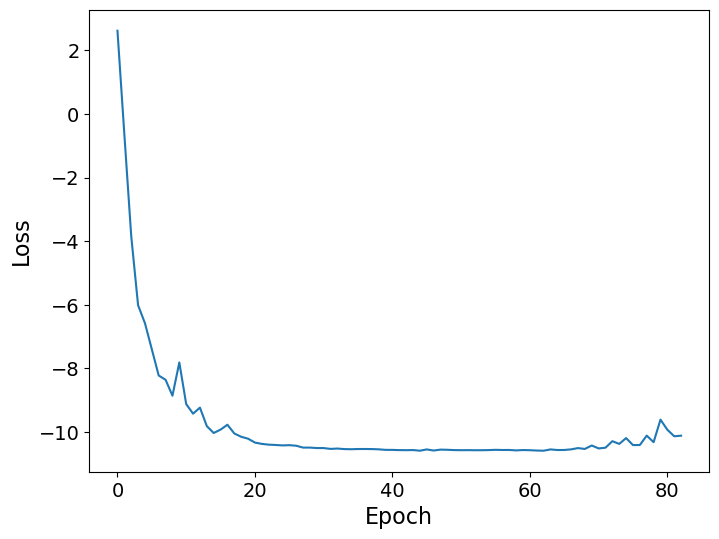

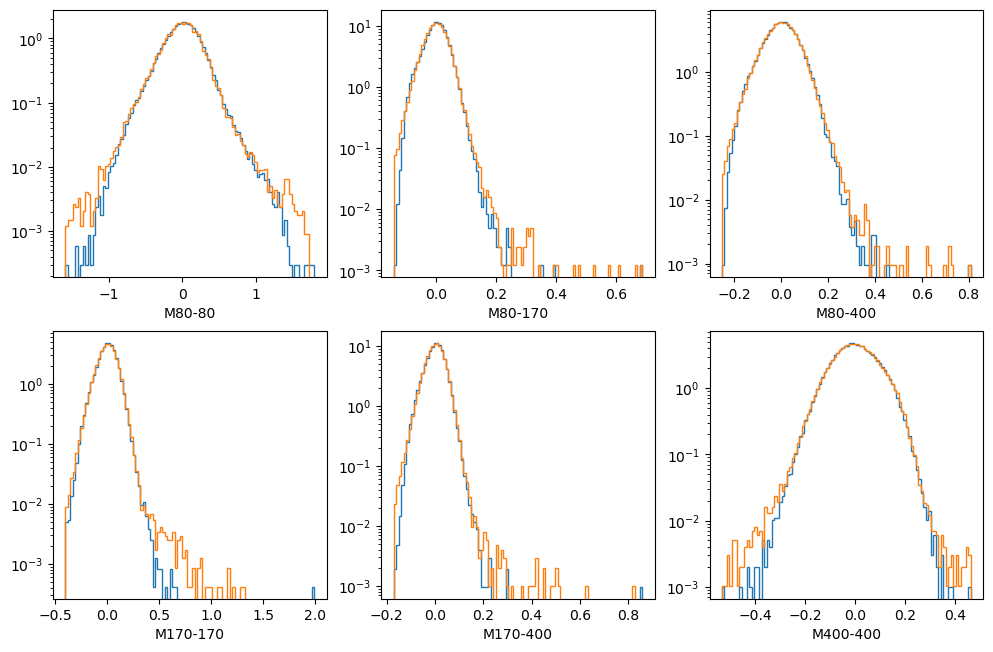

In [16]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":6,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
axes = ["M80-80","M80-170","M80-400","M170-170","M170-400","M400-400"]
flowName = 'flow1'
trainEvalLossFlow(axes,flowName,NF_kwargs,nTrain=100000,base="lossEvals_pcaDecorr_boxCox",evalBatch=50000)

100000 training events
Iteration 10 Complete
Loss:  -14.213380813598633
Iteration 20 Complete
Loss:  -17.36008071899414
Iteration 30 Complete
Loss:  -17.89739227294922
Iteration 40 Complete
Loss:  -17.974153518676758
Iteration 50 Complete
Loss:  -18.002717971801758
Iteration 60 Complete
Loss:  -17.996456146240234
Iteration 70 Complete
Loss:  -17.80452537536621


  0%|          | 0/89 [00:00<?, ?it/s]

YHH3000_H400.h5


  1%|          | 1/89 [00:20<30:28, 20.78s/it]

Wp5000_B25_T170.h5


...

 98%|█████████▊| 87/89 [14:48<00:13,  6.76s/it]

XYY5000_Y80_Yp25.h5


 99%|█████████▉| 88/89 [14:56<00:06,  6.99s/it]

XYY5000_Y80_Yp400.h5


100%|██████████| 89/89 [15:03<00:00, 10.16s/it]


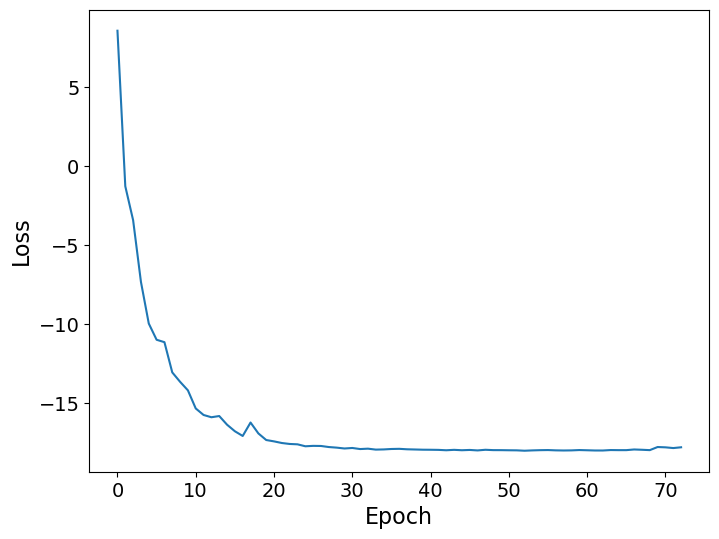

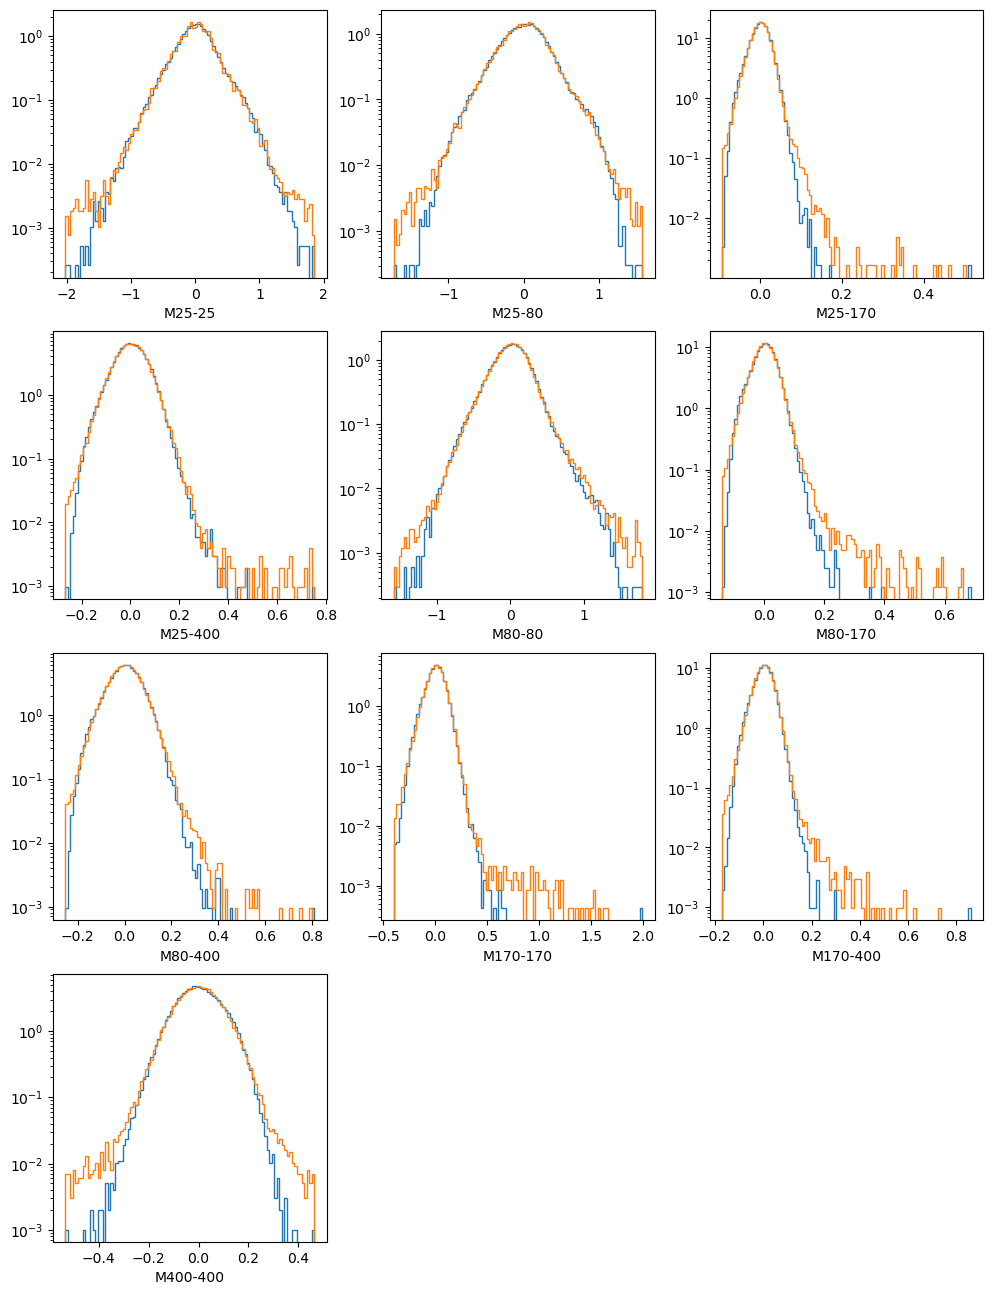

In [22]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":6,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
axes = ["M25-25","M25-80","M25-170","M25-400","M80-80","M80-170","M80-400","M170-170","M170-400","M400-400"]
flowName = 'flow0'
trainEvalLossFlow(axes,flowName,NF_kwargs,nTrain=100000,base="lossEvals_pcaDecorr_boxCox",evalBatch=50000)

# on raw losses

100000 training events
Iteration 10 Complete
Loss:  -7.216924667358398
Iteration 20 Complete
Loss:  -13.480354309082031
Iteration 30 Complete
Loss:  -15.823674201965332
Iteration 40 Complete
Loss:  -16.067777633666992
Iteration 50 Complete
Loss:  -16.131406784057617
Iteration 60 Complete
Loss:  -16.13718032836914
Iteration 70 Complete
Loss:  -16.060733795166016
Iteration 80 Complete
Loss:  -15.784611701965332


  0%|          | 0/89 [00:00<?, ?it/s]

YHH3000_H400.h5


  1%|          | 1/89 [00:09<13:39,  9.31s/it]

Wp5000_B25_T170.h5


...

 98%|█████████▊| 87/89 [07:46<00:09,  4.84s/it]

XYY5000_Y80_Yp25.h5


 99%|█████████▉| 88/89 [07:51<00:04,  4.97s/it]

XYY5000_Y80_Yp400.h5


100%|██████████| 89/89 [07:56<00:00,  5.36s/it]


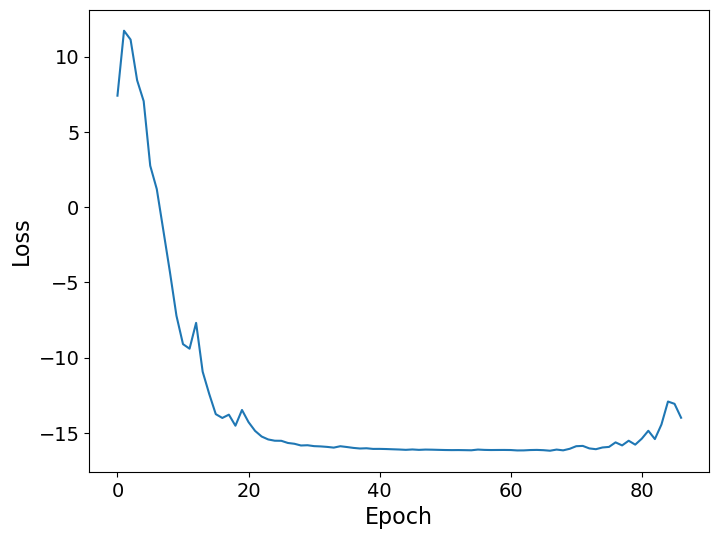

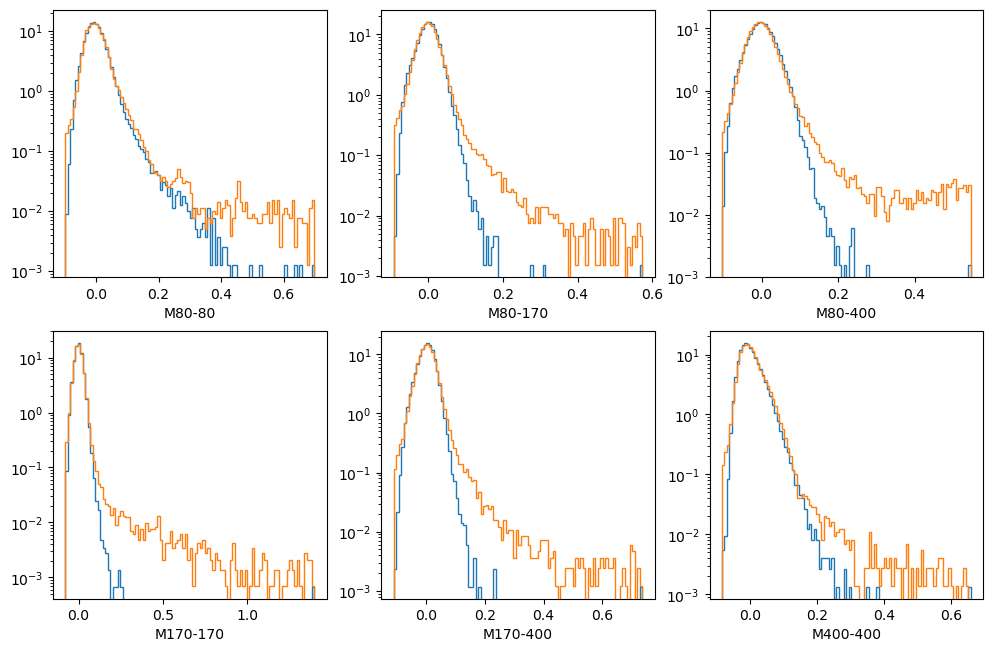

In [23]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":6,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
axes = ["M80-80","M80-170","M80-400","M170-170","M170-400","M400-400"]
flowName = 'flow1'
trainEvalLossFlow(axes,flowName,NF_kwargs,nTrain=100000,base="lossEvals",evalBatch=50000)

100000 training events
Iteration 10 Complete
Loss:  -10.863191604614258
Iteration 20 Complete
Loss:  -26.368549346923828
Iteration 30 Complete
Loss:  -28.129793167114258
Iteration 40 Complete
Loss:  -28.54344940185547
Iteration 50 Complete
Loss:  -28.655746459960938
Iteration 60 Complete
Loss:  -28.656225204467773
Iteration 70 Complete
Loss:  -27.71883773803711
Iteration 80 Complete
Loss:  -26.891246795654297


  0%|          | 0/89 [00:00<?, ?it/s]

YHH3000_H400.h5


  1%|          | 1/89 [00:13<19:16, 13.14s/it]

Wp5000_B25_T170.h5


...

 98%|█████████▊| 87/89 [10:58<00:13,  6.64s/it]

XYY5000_Y80_Yp25.h5


 99%|█████████▉| 88/89 [11:05<00:06,  6.81s/it]

XYY5000_Y80_Yp400.h5


100%|██████████| 89/89 [11:13<00:00,  7.56s/it]


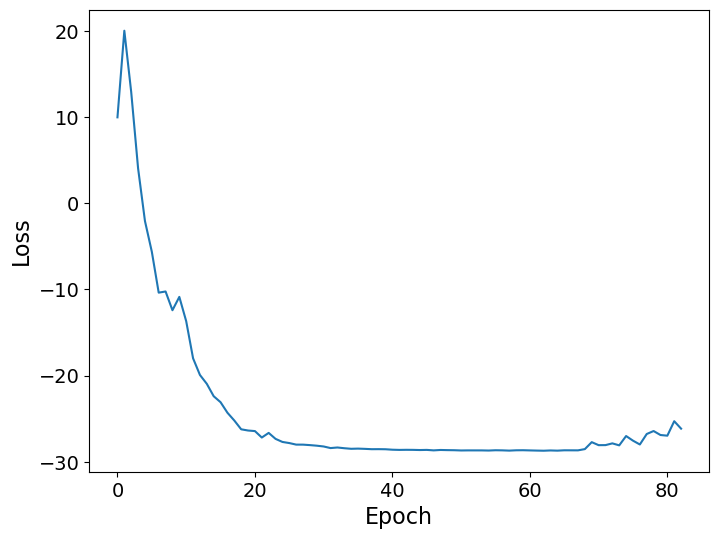

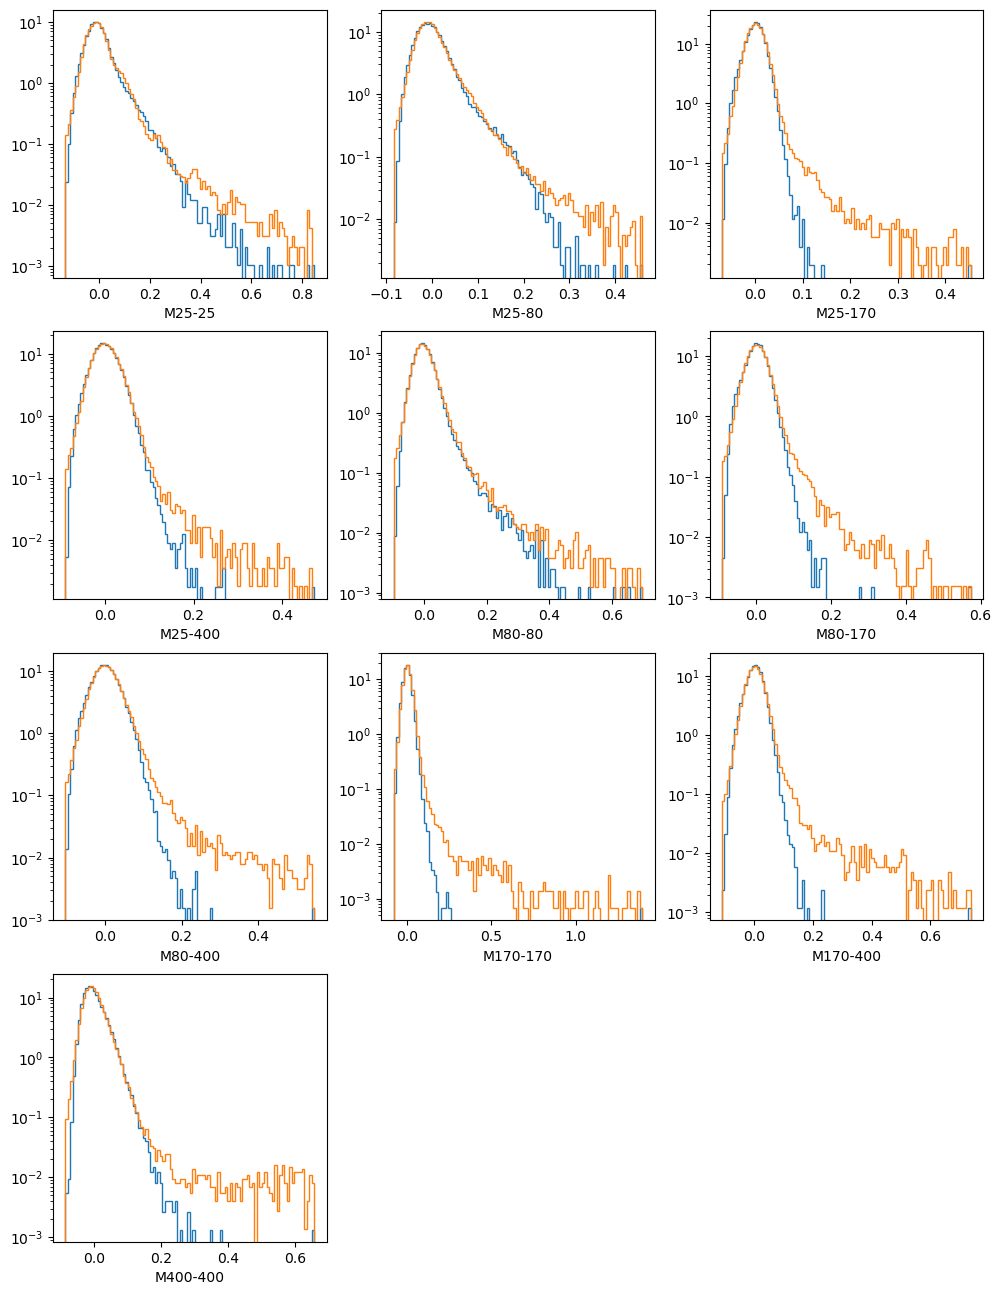

In [24]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":6,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
axes = ["M25-25","M25-80","M25-170","M25-400","M80-80","M80-170","M80-400","M170-170","M170-400","M400-400"]
flowName = 'flow0'
trainEvalLossFlow(axes,flowName,NF_kwargs,nTrain=100000,base="lossEvals",evalBatch=50000)